# 👥🚪 **Predict Customer Churn - CatBoost**

## 🏆 **Competition Overview**

**Aim**: Build a machine learning model that predicts the probability of customer churn.

**Dataset**: The provided dataset contains customer records with features related to demographics, service usage, and account details.

**Problem Type**: This is a binary classification problem - evaluated with Area Under the Receiver Operating Characteristic Curve (AUC-ROC).

**Citation**: Yao Yan, Walter Reade, Elizabeth Park. Predict Customer Churn. https://kaggle.com/competitions/playground-series-s6e3, 2026. Kaggle.

## **Index**

**🗂️ 1. [Datasets structure](#de)**

**🔎 2. [Exploratory Data Analysis (EDA)](#eda)**

* **A. [Univariate & Target-Oriented Analysis](#unitar)**
For each feature we explore, the feature and the relationship between the feature and the target.

<div style="display: flex;">
<div style="width: 25%;">
    
* [🚪 Churn](#churn)
* [🎭 Gender](#gender)
* [👴 Senior Citizen](#senior)
* [🤝 Partner](#partner)
* [👪 Dependents](#dependents)
* [📆 Tenure](#tenure)
* [📞 Phone Service](#phone)
* [☎️➕ Multiple Lines](#multiplelines)
* [🛜 Internet Service](#internet)
* [🛡️ Online Security](#onlinesecurity)

</div>

<div style="width: 25%;">

* [💾 Online Backup](#backup)
* [⛑️ DeviceProtection](#protection)
* [💻 Tech Support](#tech)
* [📺 Streaming TV](#tv)
* [🎞️ Streaming Movies](#movies)
* [📄 Contract](#contract)
* [🎫 Paperless Billing](#paperless)
* [💳 Payment Method](#payment)
* [🧾 MonthlyCharges](#monthlycharges)
* [💰 TotalCharges](#totalcharges)

</div>

</div>

* **B. [Multivariate Feature Analysis](#mfa)**

* [📏 Numerical Features](#numerical)
* [🏷️ Categorical Features](#categorical)

**🔧 3. [Feature Engineering (FE)](#fe)**

**✂️ 4. [Data preparation](#de)**

**🧠 5. [CatBoost](#cb)**

* [A. Training](#train)
* [B. Evaluation](#eval)
* [C. Predictions](#pred)

**🚀 6. [Submission](#sub)**

## **Features**

The meaningin of each feature was not available. The following definition is a personal intepretation:

 * **gender**. The customer’s gender. *Female* or *Male*.            
 * **SeniorCitizen**. Indicates whether the customer is a senior or not. Original: 0 or 1. We decide to record as 0: "No Senior", 1: "Senior".      
 * **Partner**. Whether the customer has a partner. *Yes* or *No*.             
 * **Dependents**. Whether the customer has dependents (e.g., children or financially dependent individuals). *Yes* or *No*.         
 * **tenure**. The number of months the customer has been with the company. Numerical.             
 * **PhoneService**. Indicates whether the customer subscribes to phone service. *Yes* or *No*.        
 * **MultipleLines**. Whether the customer has multiple phone lines. *No* means only one line, *Yes* mean two ore more lines and *No phone service* means other kind of services.     
 * **InternetService**. Type of internet service. *DSL*, *Fiber optic*. Only users with internet service.    
 * **OnlineSecurity**. Whether the customer subscribes to online security services. *Yes* or *No*. Only users with internet service.     
 * **OnlineBackup**. Whether the customer has an online backup service. *Yes* or *No*. Only users with internet service.           
 * **DeviceProtection**. Whether the customer has device protection coverage. *Yes* or *No*. Only users with internet service.     
 * **TechSupport**. Whether the customer subscribes to technical support services. *Yes* or *No*. Only users with internet service.          
 * **StreamingTV**. Whether the customer subscribes to streaming TV services. *Yes* or *No*. Only users with internet service.         
 * **StreamingMovies**. Whether the customer subscribes to streaming moovie services. *Yes* or *No*. Only users with internet service.     
 * **Contract**. Type of contract. *Month-to-month*, *One year*, *Two year*.           
 * **PaperlessBilling**. Whether the customer uses electronic billing. *Yes* or *No*.   
 * **PaymentMethod**. The method used for payment. There are two automatic methods, *bank transfer* and *credit card*, and two other options: *electronic check* and *mailed check*.     
 * **MonthlyCharges**. The amount charged to the customer monthly.   
 * **TotalCharges**. The total amount charged to the customer over their lifetime.      
 * **Churn**. The **target variable** indicating whether the customer left the company or stayed. *Yes* or *No*.  



In [1]:
# Libraries

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from scipy.stats import chi2_contingency
import itertools
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


# Data
train = pd.read_csv('/kaggle/input/competitions/playground-series-s6e3/train.csv', index_col = 'id')
test = pd.read_csv('/kaggle/input/competitions/playground-series-s6e3/test.csv', index_col = 'id')

# Configuration
colors = ["#6BA6D6", "#D6D16B", "#D66B70", "#6BD6D1", "#6B70D6"]

/kaggle/input/competitions/playground-series-s6e3/sample_submission.csv
/kaggle/input/competitions/playground-series-s6e3/train.csv
/kaggle/input/competitions/playground-series-s6e3/test.csv


# **🗂️ 1. Datasets structure** <a class="anchor"  id="ds"></a>

In [2]:
print(f"Train dataset has {train.shape[0]} rows and {train.shape[1]} columns")
print(f"Test dataset has {test.shape[0]} rows and {test.shape[1]} columns")

Train dataset has 594194 rows and 20 columns
Test dataset has 254655 rows and 19 columns


In [3]:
print("Count of null values in train:", train.isnull().sum().sum())
print("Count of null values in test:", test.isnull().sum().sum())

Count of null values in train: 0
Count of null values in test: 0


# **🔎 2. Exploratory Data Analysis (EDA)** <a class="anchor"  id="eda"></a>

For each feature we explore, the feature and the relationship between the feature and the target.

## **A. Univariate & Target-Oriented Analysis** <a class="anchor"  id="unitar"></a>

### **🚪 Churn** <a class="anchor"  id="churn"></a>


In [4]:
print(train["Churn"].value_counts(dropna=False))

Churn
No     460377
Yes    133817
Name: count, dtype: int64


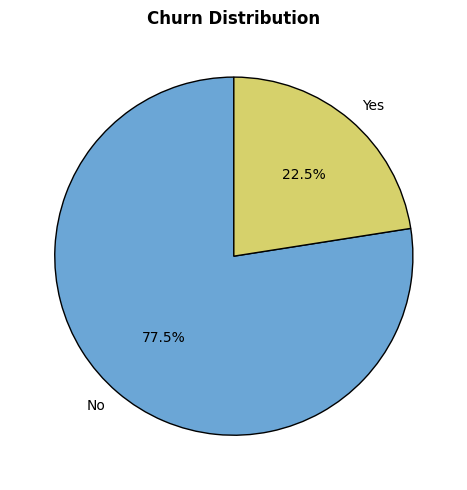

In [5]:
fig, ax = plt.subplots(figsize=(6,5))

# PLOT: Pie chart
churn_counts = train["Churn"].value_counts(dropna=False)

ax.pie(
    churn_counts,
    labels=churn_counts.index,
    colors=colors[:len(churn_counts)],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"edgecolor": "black", "linewidth": 1}
)

ax.set_title("Churn Distribution", fontweight="bold")

plt.tight_layout()
plt.show()

### **🎭 Gender** <a class="anchor"  id="gender"></a>

* Gender distribution is similar between both genders, been *female* sligthly superior than *male*. 
* Churn distribution is similar between both genders. 

In [6]:
# Gender Vs Churn
pd.crosstab(train["gender"], train["Churn"], normalize="index")

Churn,No,Yes
gender,,
Female,0.771964,0.228036
Male,0.777652,0.222348


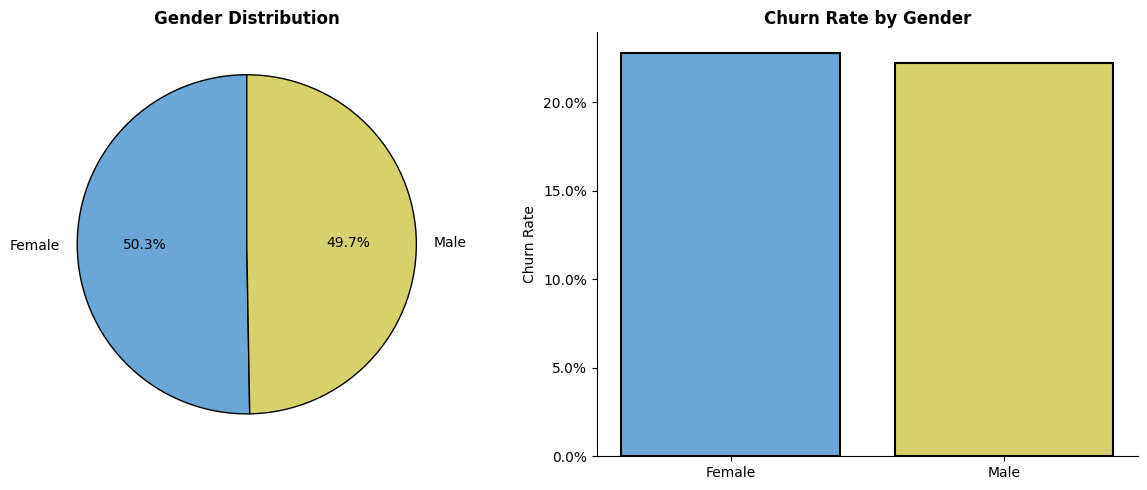

In [7]:

fig, axes = plt.subplots(1, 2, figsize=(12,5))

# PLOT: Pie chart
gender_counts = train["gender"].value_counts(dropna=False)

axes[0].pie(
    gender_counts,
    labels=gender_counts.index,
    colors=colors[:len(gender_counts)],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"edgecolor": "black", "linewidth": 1}
)

axes[0].set_title("Gender Distribution", fontweight="bold")


# PLOT: Bar chart
churn_rate_gender = pd.crosstab(
    train["gender"],
    train["Churn"],
    normalize="index"
)["Yes"]

axes[1].bar(
    churn_rate_gender.index,
    churn_rate_gender.values,
    color=colors[:len(churn_rate_gender)],
    edgecolor="black",
    linewidth=1.5
)

axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[1].set_title("Churn Rate by Gender", fontweight="bold")
axes[1].set_ylabel("Churn Rate")

axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

### **👴 Senior Citizen** <a class="anchor"  id="senior"></a>

* Only 11.4% of the customer are sensiors.
* Senior citizens exhibit a substantially higher churn rate than non-senior customers.

In [8]:
# Senior Citizen Vs Churn
pd.crosstab(train["SeniorCitizen"], train["Churn"], normalize="index")

Churn,No,Yes
SeniorCitizen,,
0,0.810226,0.189774
1,0.499683,0.500317


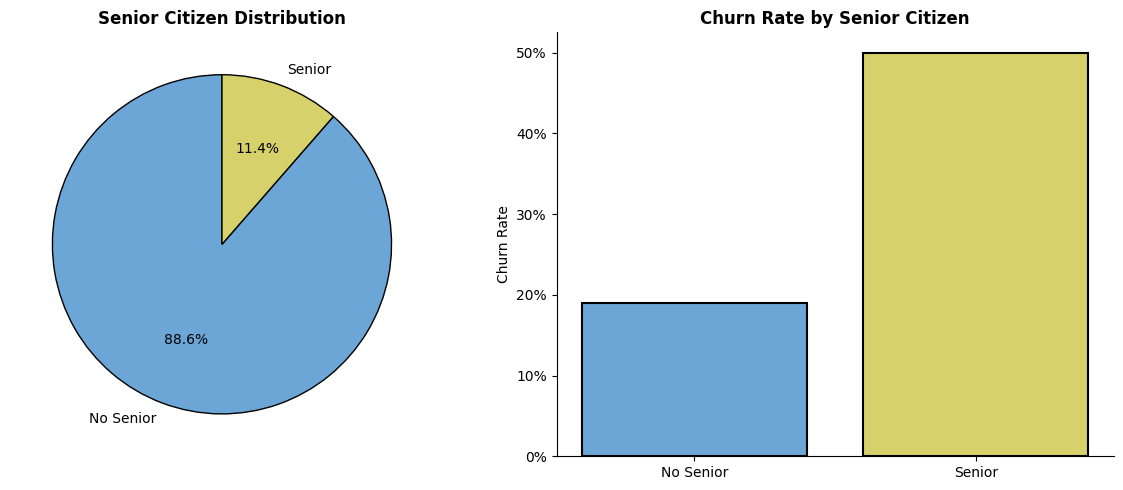

In [9]:
label_map = {0: "No Senior", 1: "Senior"}  # Labels display

fig, axes = plt.subplots(1, 2, figsize=(12,5))

# PLOT: Pie chart
senior_counts = train["SeniorCitizen"].value_counts(dropna=False)
senior_counts.index = senior_counts.index.map(label_map)

axes[0].pie(
    senior_counts,
    labels=senior_counts.index,
    colors=colors[:len(senior_counts)],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"edgecolor": "black", "linewidth": 1}
)

axes[0].set_title("Senior Citizen Distribution", fontweight="bold")


# PLOT: Bar chart
churn_rate_senior = pd.crosstab(
    train["SeniorCitizen"],
    train["Churn"],
    normalize="index"
)["Yes"]

churn_rate_senior.index = churn_rate_senior.index.map(label_map)


axes[1].bar(
    churn_rate_senior.index,
    churn_rate_senior.values,
    color=colors[:len(churn_rate_senior)],
    edgecolor="black",
    linewidth=1.5
)

axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[1].set_title("Churn Rate by Senior Citizen", fontweight="bold")
axes[1].set_ylabel("Churn Rate")

axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

### **🤝 Partner**

* The number of partners is slightly higher than no partners.
* Churn rate is higher between no partners customers.

In [10]:
# Partner Vs Churn
pd.crosstab(train["Partner"], train["Churn"], normalize="index")

Churn,No,Yes
Partner,,
No,0.675379,0.324621
Yes,0.866204,0.133796


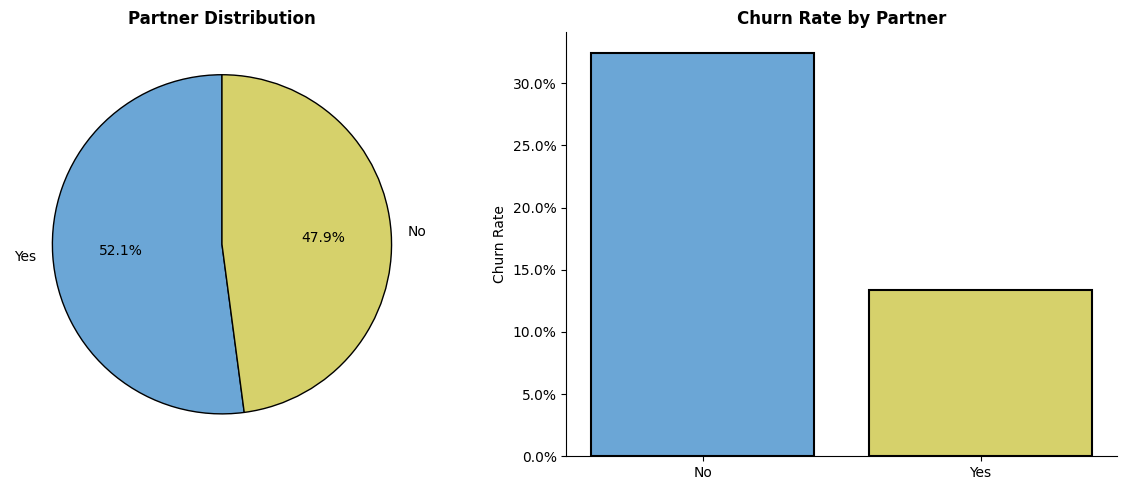

In [11]:

fig, axes = plt.subplots(1, 2, figsize=(12,5))

# PLOT: Pie chart
partner_counts = train["Partner"].value_counts(dropna=False)

axes[0].pie(
    partner_counts,
    labels=partner_counts.index,
    colors=colors[:len(partner_counts)],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"edgecolor": "black", "linewidth": 1}
)

axes[0].set_title("Partner Distribution", fontweight="bold")


# PLOT: Bar chart
churn_rate_partner = pd.crosstab(
    train["Partner"],
    train["Churn"],
    normalize="index"
)["Yes"]

axes[1].bar(
    churn_rate_partner.index,
    churn_rate_partner.values,
    color=colors[:len(churn_rate_partner)],
    edgecolor="black",
    linewidth=1.5
)

axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[1].set_title("Churn Rate by Partner", fontweight="bold")
axes[1].set_ylabel("Churn Rate")

axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

### **👪 Dependents** <a class="anchor"  id="dependents"></a>

* Most of the customer are no dependents.
* No dependents exhibit a substantially higher churn rate than non-senior customers.

In [12]:
# Dependents Vs Churn
pd.crosstab(train["Dependents"], train["Churn"], normalize="index")

Churn,No,Yes
Dependents,,
No,0.708646,0.291354
Yes,0.927204,0.072796


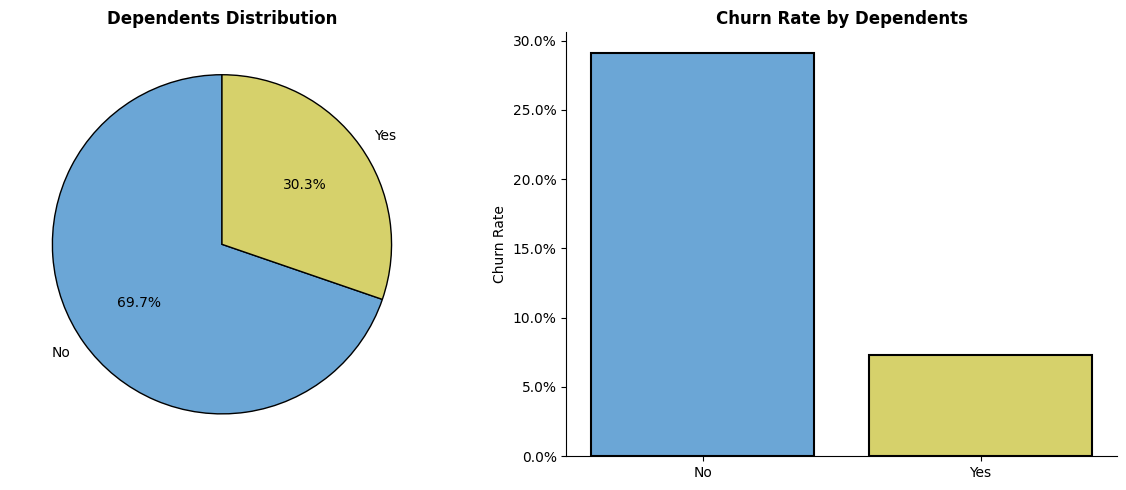

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# PLOT: Pie chart
dependents_counts = train["Dependents"].value_counts(dropna=False)

axes[0].pie(
    dependents_counts,
    labels=dependents_counts.index,
    colors=colors[:len(dependents_counts)],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"edgecolor": "black", "linewidth": 1}
)

axes[0].set_title("Dependents Distribution", fontweight="bold")


# PLOT: Bar chart
churn_rate_dependents = pd.crosstab(
    train["Dependents"],
    train["Churn"],
    normalize="index"
)["Yes"]

axes[1].bar(
    churn_rate_dependents.index,
    churn_rate_dependents.values,
    color=colors[:len(churn_rate_dependents)],
    edgecolor="black",
    linewidth=1.5
)

axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[1].set_title("Churn Rate by Dependents", fontweight="bold")
axes[1].set_ylabel("Churn Rate")

axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

### **📆 Tenure** <a class="anchor"  id="tenure"></a>

* Tenure ranges between 1 month and 72 months (around 6 years). Mean tenure is 36.58 months with a standard deviation of 25.062.
* Tenure is widely distributed with noticeable concentration at very low and very high values, suggesting early churn risk and long-term customer retention clusters.
* Customers who churn have significantly lower tenure (mean = 17.13) compared to retained customers (mean = 42.23).

In [14]:
train["tenure"].describe()

count    594194.000000
mean         36.577258
std          25.061922
min           1.000000
25%          12.000000
50%          35.000000
75%          62.000000
max          72.000000
Name: tenure, dtype: float64

In [15]:
# Tenure vs Churn
train.groupby("Churn")["tenure"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,460377.0,42.231313,23.987158,1.0,20.0,46.0,66.0,72.0
Yes,133817.0,17.125343,17.919396,1.0,3.0,10.0,25.0,72.0


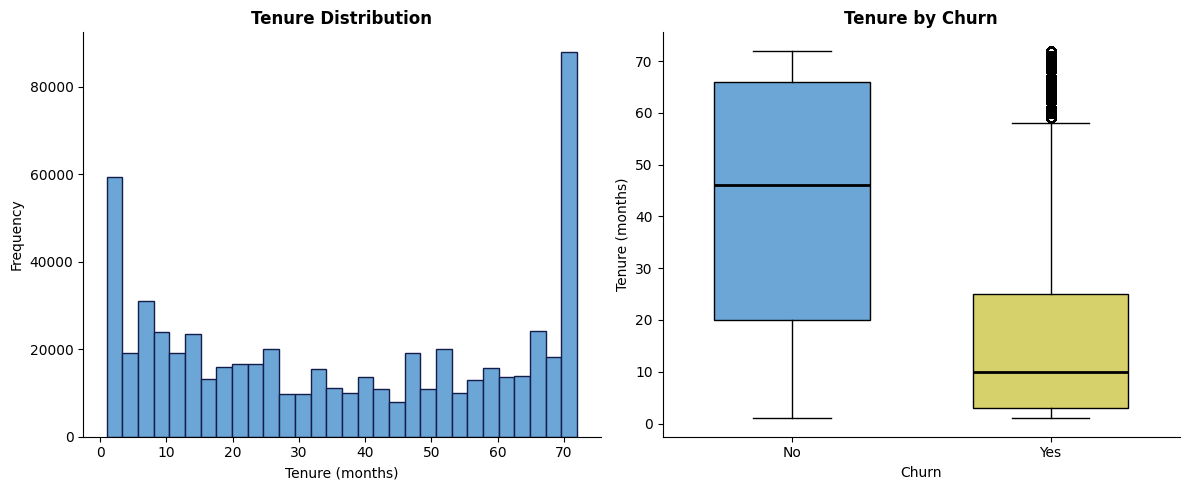

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# PLOT: Histogram
axes[0].hist(
    train["tenure"],
    bins=30,
    color="#6BA6D6",
    edgecolor="#141C4C"
)

axes[0].set_title("Tenure Distribution", fontweight="bold")
axes[0].set_xlabel("Tenure (months)")
axes[0].set_ylabel("Frequency")

axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

# PLOT: Boxplot
data_churn_tenure = [
    train[train["Churn"] == "No"]["tenure"],
    train[train["Churn"] == "Yes"]["tenure"]
]

bplot = axes[1].boxplot(
    data_churn_tenure,
    patch_artist=True,
    tick_labels=["No", "Yes"],
    widths=0.6,
    medianprops=dict(color="black", linewidth=2)
)

for patch, color in zip(bplot["boxes"], colors):
    patch.set_facecolor(color)

axes[1].set_title("Tenure by Churn", fontweight="bold")
axes[1].set_xlabel("Churn")
axes[1].set_ylabel("Tenure (months)")

axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

### **📞 Phone Service** <a class="anchor"  id="phone"></a>

* Around 94% of the customer have a phone service.
* Customers that have phone services have more posibilities of churn.

In [17]:
# Phone Service Vs Churn
pd.crosstab(train["PhoneService"], train["Churn"], normalize="index")

Churn,No,Yes
PhoneService,,
No,0.83185,0.16815
Yes,0.77108,0.22892


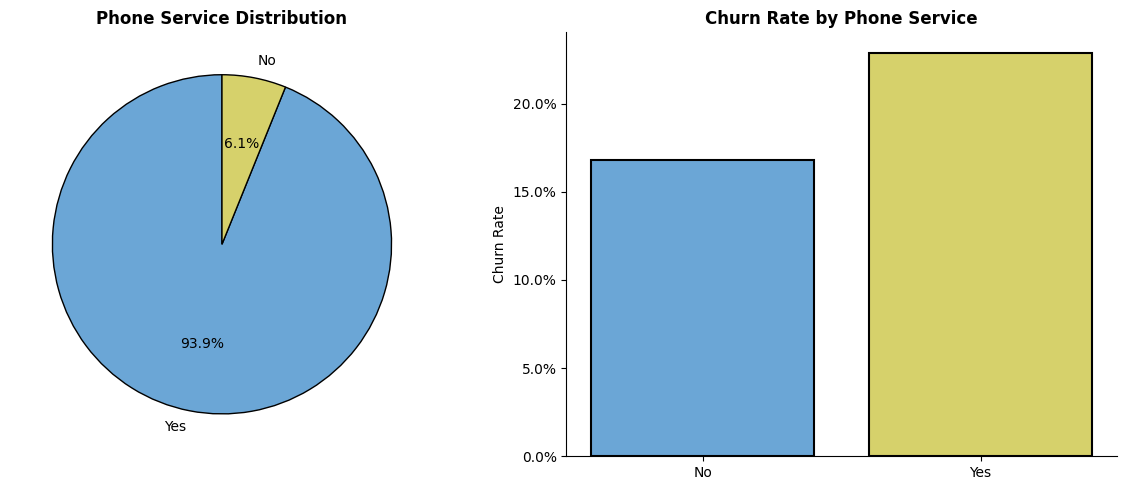

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# PLOT: Pie chart
phone_counts = train["PhoneService"].value_counts(dropna=False)

axes[0].pie(
    phone_counts,
    labels=phone_counts.index,
    colors=colors[:len(phone_counts)],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"edgecolor": "black", "linewidth": 1}
)

axes[0].set_title("Phone Service Distribution", fontweight="bold")


# PLOT: Bar chart
churn_rate_phone = pd.crosstab(
    train["PhoneService"],
    train["Churn"],
    normalize="index"
)["Yes"]

axes[1].bar(
    churn_rate_phone.index,
    churn_rate_phone.values,
    color=colors[:len(churn_rate_phone)],
    edgecolor="black",
    linewidth=1.5
)

axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[1].set_title("Churn Rate by Phone Service", fontweight="bold")
axes[1].set_ylabel("Churn Rate")

axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

### **☎️➕ Multiple Lines** <a class="anchor"  id="multiplelines"></a>

* Between users that have phone services there is no difference between the amount of customer that have one ore multple lines.
* The churn rate is higher between that users that have more than one line.

In [19]:
# Phone Service Vs Churn
pd.crosstab(train["MultipleLines"], train["Churn"], normalize="index")

Churn,No,Yes
MultipleLines,,
No,0.817678,0.182322
No phone service,0.831850,0.168150
Yes,0.722974,0.277026


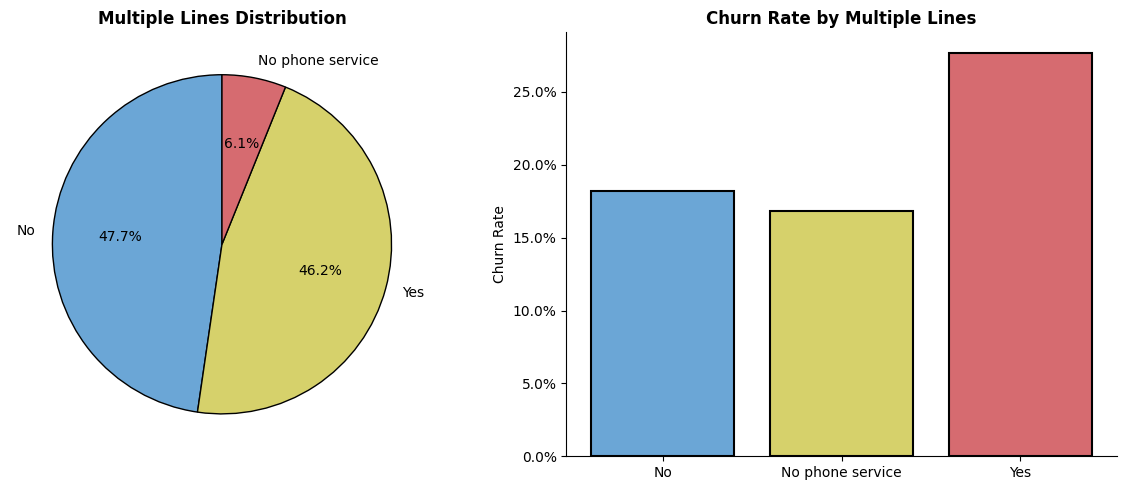

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# PLOT: Pie chart
lines_counts = train["MultipleLines"].value_counts(dropna=False)

axes[0].pie(
    lines_counts,
    labels=lines_counts.index,
    colors=colors[:len(lines_counts)],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"edgecolor": "black", "linewidth": 1}
)

axes[0].set_title("Multiple Lines Distribution", fontweight="bold")


# PLOT: Bar chart
churn_rate_lines = pd.crosstab(
    train["MultipleLines"],
    train["Churn"],
    normalize="index"
)["Yes"]

axes[1].bar(
    churn_rate_lines.index,
    churn_rate_lines.values,
    color=colors[:len(churn_rate_lines)],
    edgecolor="black",
    linewidth=1.5
)

axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[1].set_title("Churn Rate by Multiple Lines", fontweight="bold")
axes[1].set_ylabel("Churn Rate")

axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

### **🛜 Internet Service** <a class="anchor"  id="internet"></a>

* When a customer has an internet service, it use to be *fiber optic*. The amount of customer that have *DSL* is slightly higher that the proportion of user that don't have an internet sevice.
* Customers with a *Fiber optic* service are more churn.

In [21]:
# Internet Service Vs Churn
pd.crosstab(train["InternetService"], train["Churn"], normalize="index")

Churn,No,Yes
InternetService,,
DSL,0.896936,0.103064
Fiber optic,0.584634,0.415366
No,0.985689,0.014311


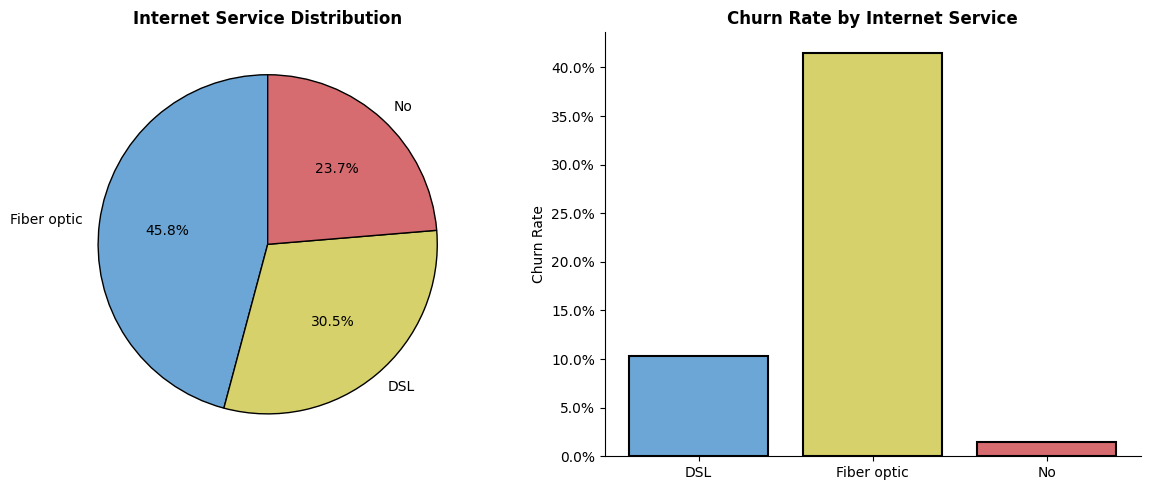

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# PLOT: Pie chart
internet_counts = train["InternetService"].value_counts(dropna=False)

axes[0].pie(
    internet_counts,
    labels=internet_counts.index,
    colors=colors[:len(internet_counts)],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"edgecolor": "black", "linewidth": 1}
)

axes[0].set_title("Internet Service Distribution", fontweight="bold")


# PLOT: Bar chart
churn_rate_internet = pd.crosstab(
    train["InternetService"],
    train["Churn"],
    normalize="index"
)["Yes"]

axes[1].bar(
    churn_rate_internet.index,
    churn_rate_internet.values,
    color=colors[:len(churn_rate_internet)],
    edgecolor="black",
    linewidth=1.5
)

axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[1].set_title("Churn Rate by Internet Service", fontweight="bold")
axes[1].set_ylabel("Churn Rate")

axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

### **🛡️ Online Security** <a class="anchor"  id="onlinesecurity"></a>

* Most of the users don't have online security package.
* Most of the churns are customers without only security.

In [23]:
# Online Security Vs Churn
pd.crosstab(train["OnlineSecurity"], train["Churn"], normalize="index")

Churn,No,Yes
OnlineSecurity,,
No,0.593867,0.406133
No internet service,0.985689,0.014311
Yes,0.913179,0.086821


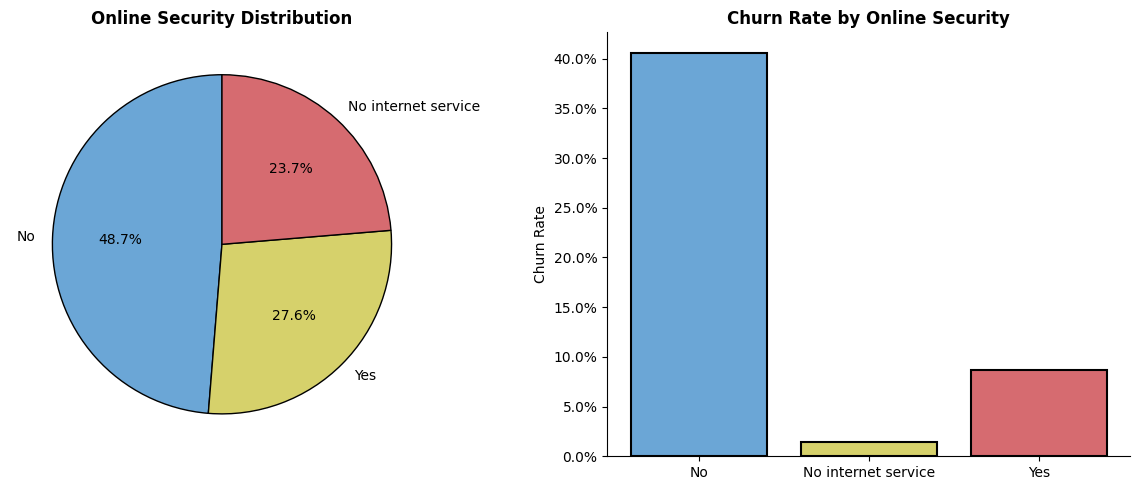

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# PLOT: Pie chart
security_counts = train["OnlineSecurity"].value_counts(dropna=False)

axes[0].pie(
    security_counts,
    labels=security_counts.index,
    colors=colors[:len(security_counts)],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"edgecolor": "black", "linewidth": 1}
)

axes[0].set_title("Online Security Distribution", fontweight="bold")


# PLOT: Bar chart
churn_rate_security = pd.crosstab(
    train["OnlineSecurity"],
    train["Churn"],
    normalize="index"
)["Yes"]

axes[1].bar(
    churn_rate_security.index,
    churn_rate_security.values,
    color=colors[:len(churn_rate_security)],
    edgecolor="black",
    linewidth=1.5
)

axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[1].set_title("Churn Rate by Online Security", fontweight="bold")
axes[1].set_ylabel("Churn Rate")

axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

### **💾 Online Backup** <a class="anchor"  id="backup"></a>

* The distribution between user that have online backup and the ones that haven't got it is similar.
* The proportion of churn customer is higher between that users that don't have an online backup.

In [25]:
# Online Backup Vs Churn
pd.crosstab(train["OnlineBackup"], train["Churn"], normalize="index")

Churn,No,Yes
OnlineBackup,,
No,0.608974,0.391026
No internet service,0.985689,0.014311
Yes,0.832760,0.167240


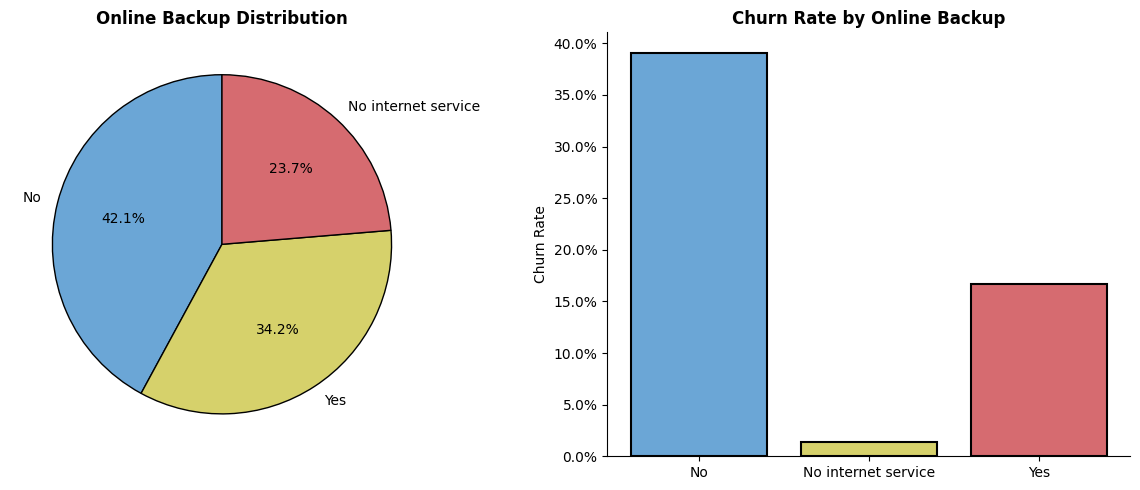

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# PLOT: Pie chart
backup_counts = train["OnlineBackup"].value_counts(dropna=False)

axes[0].pie(
    backup_counts,
    labels=backup_counts.index,
    colors=colors[:len(backup_counts)],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"edgecolor": "black", "linewidth": 1}
)

axes[0].set_title("Online Backup Distribution", fontweight="bold")


# PLOT: Bar chart
churn_rate_backup = pd.crosstab(
    train["OnlineBackup"],
    train["Churn"],
    normalize="index"
)["Yes"]

axes[1].bar(
    churn_rate_backup.index,
    churn_rate_backup.values,
    color=colors[:len(churn_rate_backup)],
    edgecolor="black",
    linewidth=1.5
)

axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[1].set_title("Churn Rate by Online Backup", fontweight="bold")
axes[1].set_ylabel("Churn Rate")

axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

### **⛑️ Device Protection** <a class="anchor"  id="protection"></a>

* The number of users without device protection is slightly higher than the number of users who have it.
* The churn rate is higher among users who do not have device protection compared to those who do.

In [27]:
# Device Protection Vs Churn
pd.crosstab(train["DeviceProtection"], train["Churn"], normalize="index")

Churn,No,Yes
DeviceProtection,,
No,0.619370,0.380630
No internet service,0.985689,0.014311
Yes,0.817342,0.182658


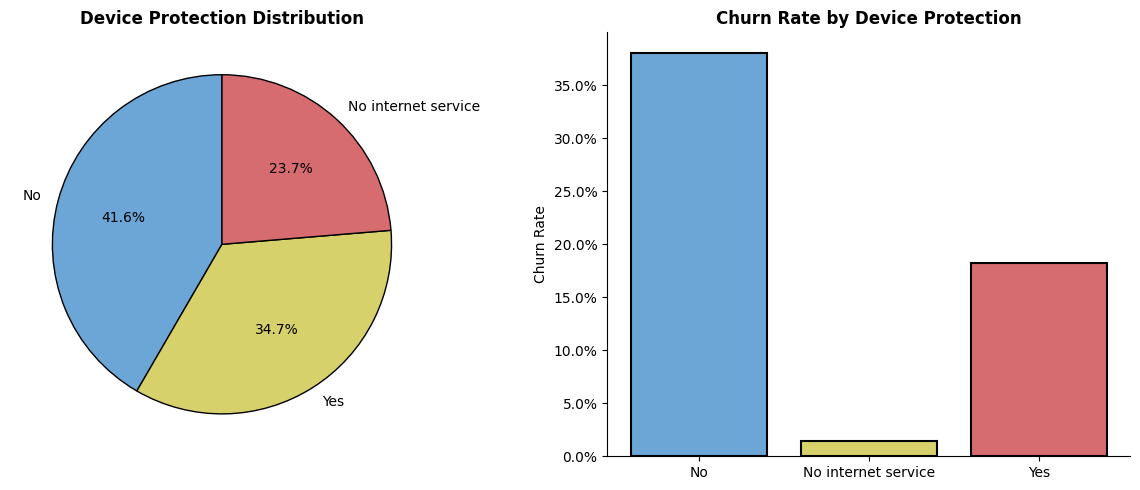

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# PLOT: Pie chart
protection_counts = train["DeviceProtection"].value_counts(dropna=False)

axes[0].pie(
    protection_counts,
    labels=protection_counts.index,
    colors=colors[:len(protection_counts)],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"edgecolor": "black", "linewidth": 1}
)

axes[0].set_title("Device Protection Distribution", fontweight="bold")


# PLOT: Bar chart
churn_rate_protection = pd.crosstab(
    train["DeviceProtection"],
    train["Churn"],
    normalize="index"
)["Yes"]

axes[1].bar(
    churn_rate_protection.index,
    churn_rate_protection.values,
    color=colors[:len(churn_rate_protection)],
    edgecolor="black",
    linewidth=1.5
)

axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[1].set_title("Churn Rate by Device Protection", fontweight="bold")
axes[1].set_ylabel("Churn Rate")

axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

### **💻 Tech Support** <a class="anchor"  id="tech"></a>

* The number of users without tech support is slightly higher than the number of users who have it.
* The churn rate is higher among users who do not have tech support compared to those who do.

In [29]:
# Tech Support Vs Churn
pd.crosstab(train["TechSupport"], train["Churn"], normalize="index")

Churn,No,Yes
TechSupport,,
No,0.598380,0.401620
No internet service,0.985689,0.014311
Yes,0.903533,0.096467


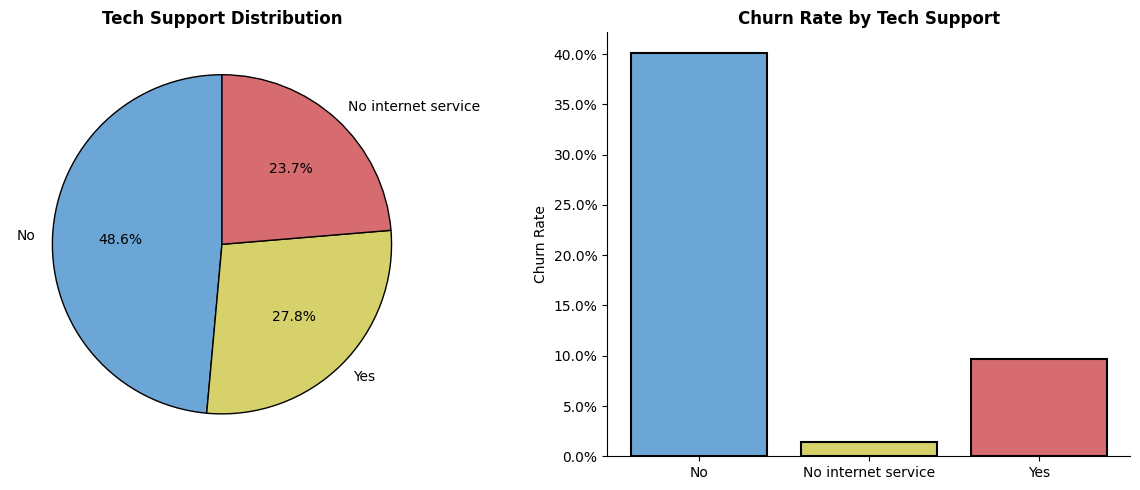

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# PLOT: Pie chart
tech_counts = train["TechSupport"].value_counts(dropna=False)

axes[0].pie(
    tech_counts,
    labels=tech_counts.index,
    colors=colors[:len(tech_counts)],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"edgecolor": "black", "linewidth": 1}
)

axes[0].set_title("Tech Support Distribution", fontweight="bold")


# PLOT: Bar chart
churn_rate_tech = pd.crosstab(
    train["TechSupport"],
    train["Churn"],
    normalize="index"
)["Yes"]

axes[1].bar(
    churn_rate_tech.index,
    churn_rate_tech.values,
    color=colors[:len(churn_rate_tech)],
    edgecolor="black",
    linewidth=1.5
)

axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[1].set_title("Churn Rate by Tech Support", fontweight="bold")
axes[1].set_ylabel("Churn Rate")

axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

### **📺 Streaming TV** <a class="anchor"  id="tv"></a>

* The number of users with streaming TV service is slightly higher than the number of users who don't have it.
* The churn rate is similar among users with and without streaming TV.

In [31]:
# Streaming TV Vs Churn
pd.crosstab(train["StreamingTV"], train["Churn"], normalize="index")

Churn,No,Yes
StreamingTV,,
No,0.702584,0.297416
No internet service,0.985689,0.014311
Yes,0.715340,0.284660


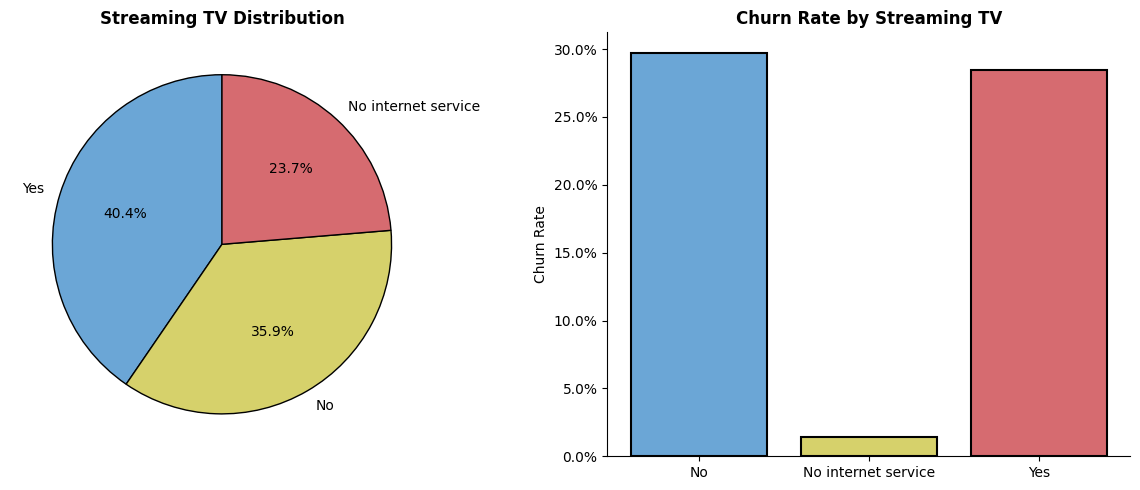

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# PLOT: Pie chart
tv_counts = train["StreamingTV"].value_counts(dropna=False)

axes[0].pie(
    tv_counts,
    labels=tv_counts.index,
    colors=colors[:len(tv_counts)],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"edgecolor": "black", "linewidth": 1}
)

axes[0].set_title("Streaming TV Distribution", fontweight="bold")


# PLOT: Bar chart
churn_rate_tv = pd.crosstab(
    train["StreamingTV"],
    train["Churn"],
    normalize="index"
)["Yes"]

axes[1].bar(
    churn_rate_tv.index,
    churn_rate_tv.values,
    color=colors[:len(churn_rate_tv)],
    edgecolor="black",
    linewidth=1.5
)

axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[1].set_title("Churn Rate by Streaming TV", fontweight="bold")
axes[1].set_ylabel("Churn Rate")

axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

### **🎞️ Streaming Movies** <a class="anchor"  id="movies"></a>

* The number of users with streaming movies service is slightly higher than the number of users who don't have it.
* The churn rate is similar among users with and without streaming movies service.

In [33]:
# Streaming Movies Vs Churn
pd.crosstab(train["StreamingMovies"], train["Churn"], normalize="index")

Churn,No,Yes
StreamingMovies,,
No,0.700701,0.299299
No internet service,0.985689,0.014311
Yes,0.716934,0.283066


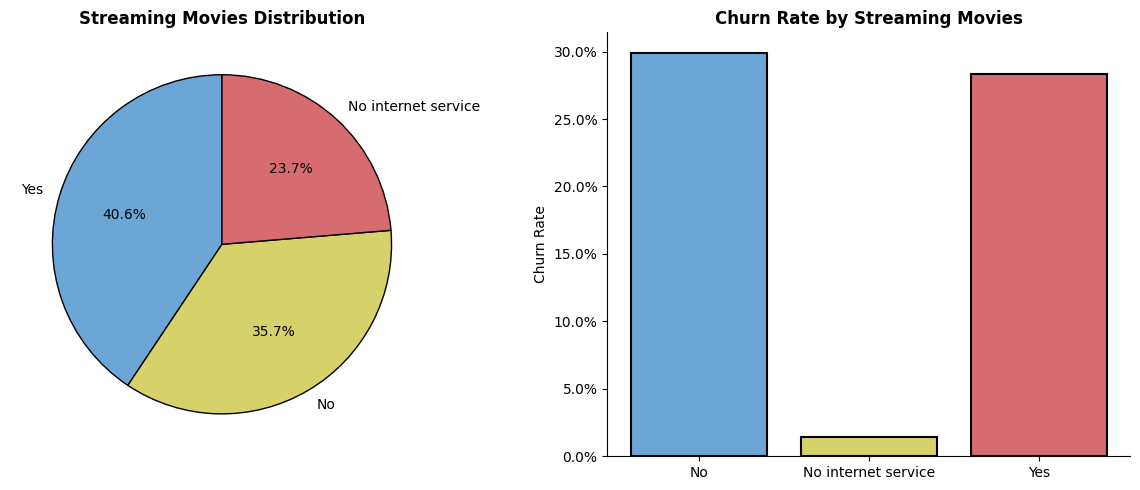

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# PLOT: Pie chart
movies_counts = train["StreamingMovies"].value_counts(dropna=False)

axes[0].pie(
    movies_counts,
    labels=movies_counts.index,
    colors=colors[:len(movies_counts)],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"edgecolor": "black", "linewidth": 1}
)

axes[0].set_title("Streaming Movies Distribution", fontweight="bold")


# PLOT: Bar chart
churn_rate_movies = pd.crosstab(
    train["StreamingMovies"],
    train["Churn"],
    normalize="index"
)["Yes"]

axes[1].bar(
    churn_rate_movies.index,
    churn_rate_movies.values,
    color=colors[:len(churn_rate_movies)],
    edgecolor="black",
    linewidth=1.5
)

axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[1].set_title("Churn Rate by Streaming Movies", fontweight="bold")
axes[1].set_ylabel("Churn Rate")

axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

### **📄 Contract** <a class="anchor"  id="contract"></a>

* Most of the customers have a month-to-month contract.
* The churn is higher between that users that have a month-to-month contract.

In [35]:
# Contract Vs Churn
pd.crosstab(train["Contract"], train["Churn"], normalize="index")

Churn,No,Yes
Contract,,
Month-to-month,0.579457,0.420543
One year,0.942372,0.057628
Two year,0.990018,0.009982


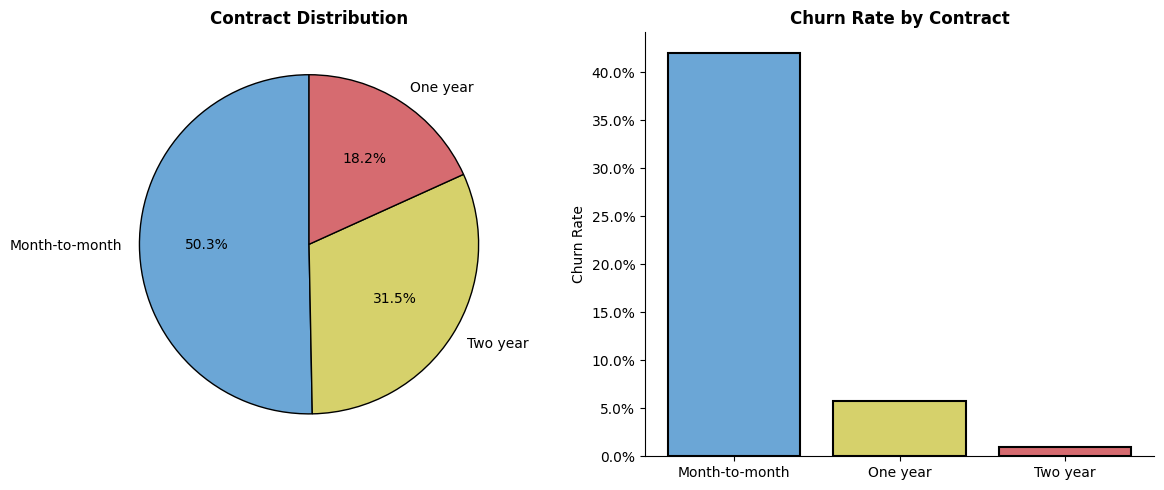

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# PLOT: Pie chart
contract_counts = train["Contract"].value_counts(dropna=False)

axes[0].pie(
    contract_counts,
    labels=contract_counts.index,
    colors=colors[:len(contract_counts)],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"edgecolor": "black", "linewidth": 1}
)

axes[0].set_title("Contract Distribution", fontweight="bold")


# PLOT: Bar chart
churn_rate_contract = pd.crosstab(
    train["Contract"],
    train["Churn"],
    normalize="index"
)["Yes"]

axes[1].bar(
    churn_rate_contract.index,
    churn_rate_contract.values,
    color=colors[:len(churn_rate_contract)],
    edgecolor="black",
    linewidth=1.5
)

axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[1].set_title("Churn Rate by Contract", fontweight="bold")
axes[1].set_ylabel("Churn Rate")

axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

### **🎫 Paperless Billing** <a class="anchor"  id="paperless"></a>

* A 61.5% of the customer have an online bill.
* The churn proportion is higher between that user that have an online billing.

In [37]:
# Paperless Billing Vs Churn
pd.crosstab(train["PaperlessBilling"], train["Churn"], normalize="index")

Churn,No,Yes
PaperlessBilling,,
No,0.925394,0.074606
Yes,0.680613,0.319387


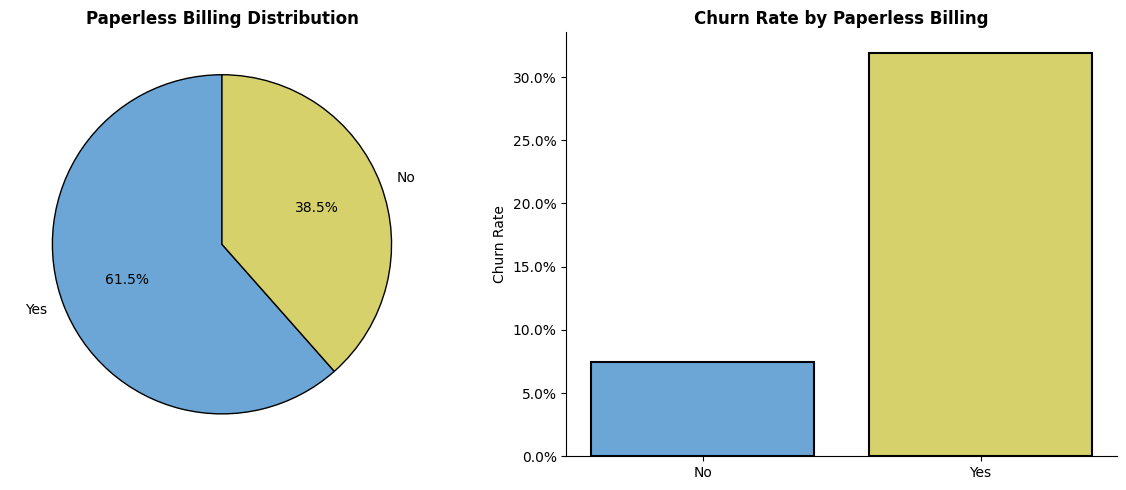

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# PLOT: Pie chart
paper_counts = train["PaperlessBilling"].value_counts(dropna=False)

axes[0].pie(
    paper_counts,
    labels=paper_counts.index,
    colors=colors[:len(paper_counts)],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"edgecolor": "black", "linewidth": 1}
)

axes[0].set_title("Paperless Billing Distribution", fontweight="bold")


# PLOT: Bar chart
churn_rate_paper = pd.crosstab(
    train["PaperlessBilling"],
    train["Churn"],
    normalize="index"
)["Yes"]

axes[1].bar(
    churn_rate_paper.index,
    churn_rate_paper.values,
    color=colors[:len(churn_rate_paper)],
    edgecolor="black",
    linewidth=1.5
)

axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[1].set_title("Churn Rate by Paperless Billing", fontweight="bold")
axes[1].set_ylabel("Churn Rate")

axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

### **💳 Payment Method** <a class="anchor"  id="payment"></a>

* Most customers use *electronic check* as their payment method, while the remaining customers are distributed across the other payment options.
* The churn rate is significantly higher among customers who use the electronic check payment method.

In [39]:
# Payment Method Vs Churn
pd.crosstab(train["PaymentMethod"], train["Churn"], normalize="index")

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),0.922907,0.077093
Credit card (automatic),0.930668,0.069332
Electronic check,0.510948,0.489052
Mailed check,0.920303,0.079697


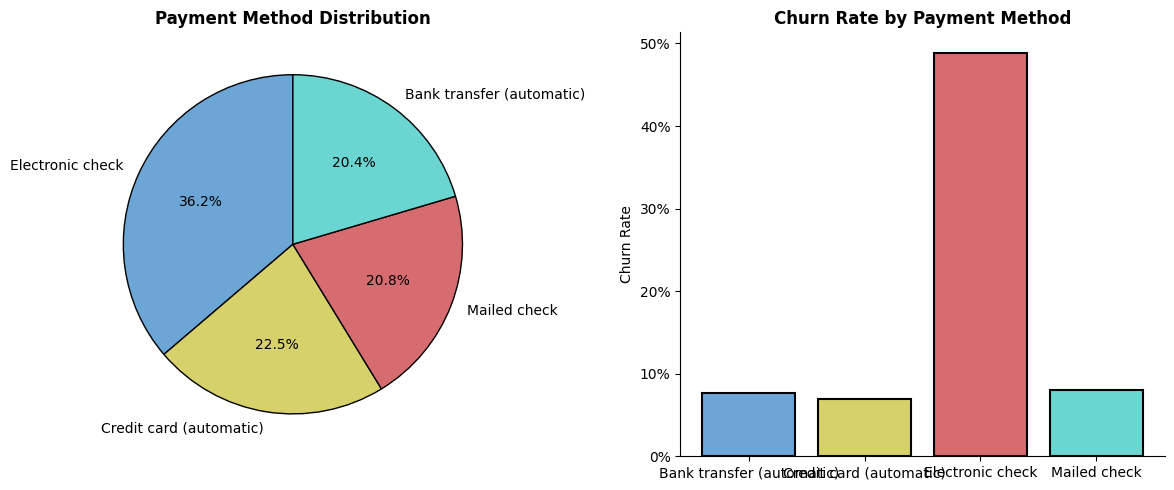

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# PLOT: Pie chart
pay_counts = train["PaymentMethod"].value_counts(dropna=False)

axes[0].pie(
    pay_counts,
    labels=pay_counts.index,
    colors=colors[:len(pay_counts)],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"edgecolor": "black", "linewidth": 1}
)

axes[0].set_title("Payment Method Distribution", fontweight="bold")


# PLOT: Bar chart
churn_rate_pay = pd.crosstab(
    train["PaymentMethod"],
    train["Churn"],
    normalize="index"
)["Yes"]

axes[1].bar(
    churn_rate_pay.index,
    churn_rate_pay.values,
    color=colors[:len(churn_rate_pay)],
    edgecolor="black",
    linewidth=1.5
)

axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[1].set_title("Churn Rate by Payment Method", fontweight="bold")
axes[1].set_ylabel("Churn Rate")

axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

### **🧾Monthly Charges** <a class="anchor"  id="monthlycharges"></a>

* Monthly charges vary from 18.25 to 118.75 with a mean of 68.87 and a standard deviation of 31.067.
* Monthly charges show a strong concentration around ~20 (likely a base plan), with additional density across higher pricing tiers.
* Churned customers have significantly higher monthly charges.

In [41]:
train["MonthlyCharges"].describe()

count    594194.000000
mean         65.866223
std          31.067444
min          18.250000
25%          29.900000
50%          74.100000
75%          90.800000
max         118.750000
Name: MonthlyCharges, dtype: float64

In [42]:
# Monthly Charges vs Churn
train.groupby("Churn")["MonthlyCharges"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,460377.0,61.293633,32.287427,18.25,24.25,65.40,89.20,118.75
Yes,133817.0,81.597525,19.490306,18.80,74.30,85.05,95.25,118.75


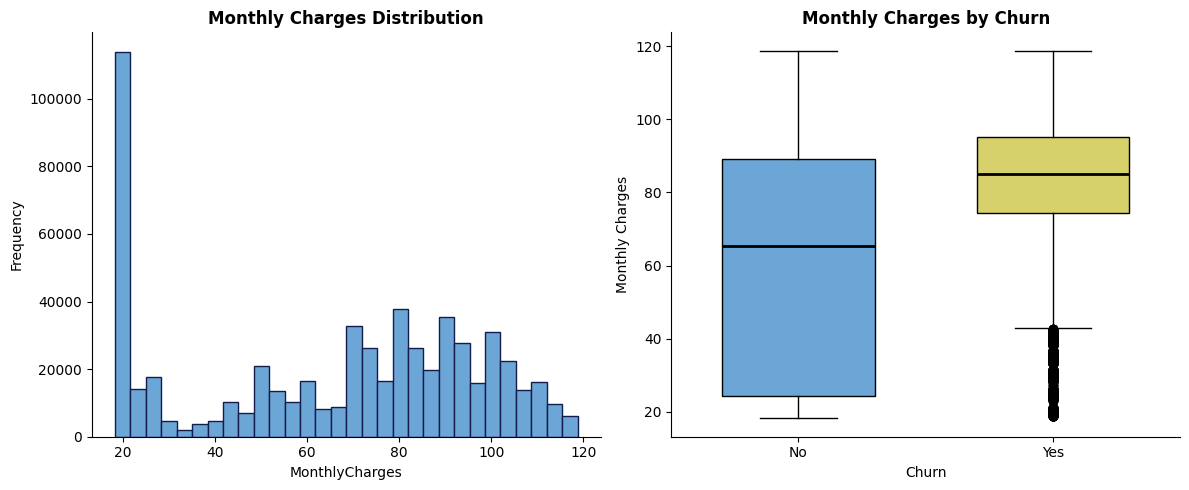

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# PLOT: Histogram
axes[0].hist(
    train["MonthlyCharges"],
    bins=30,
    color="#6BA6D6",
    edgecolor="#141C4C"
)

axes[0].set_title("Monthly Charges Distribution", fontweight="bold")
axes[0].set_xlabel("MonthlyCharges")
axes[0].set_ylabel("Frequency")

axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

# PLOT: Boxplot
data_churn_monthlycharges = [
    train[train["Churn"] == "No"]["MonthlyCharges"],
    train[train["Churn"] == "Yes"]["MonthlyCharges"]
]

bplot = axes[1].boxplot(
    data_churn_monthlycharges,
    patch_artist=True,
    tick_labels=["No", "Yes"],
    widths=0.6,
    medianprops=dict(color="black", linewidth=2)
)

for patch, color in zip(bplot["boxes"], colors):
    patch.set_facecolor(color)

axes[1].set_title("Monthly Charges by Churn", fontweight="bold")
axes[1].set_xlabel("Churn")
axes[1].set_ylabel("Monthly Charges")

axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

### **💰 Total Charges** <a class="anchor"  id="totalcharges"></a>

* Total charges vary from 18.80 to 8684.80 with a mean of 2494.38 and a standard deviation of 2353.917.
* Total charges are heavily right-skewed, with most customers accumulating relatively low total charges and a long tail of high-spending customers
* Customers who churn have substantially lower total charges than retained customers.

In [44]:
train["TotalCharges"].describe()

count    594194.000000
mean       2494.377057
std        2353.916710
min          18.800000
25%         639.650000
50%        1433.650000
75%        4263.800000
max        8684.800000
Name: TotalCharges, dtype: float64

In [45]:
# Total Charges vs Churn
train.groupby("Churn")["TotalCharges"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,460377.0,2771.500515,2423.054655,18.8,772.30,1688.75,4759.55,8684.8
Yes,133817.0,1540.976020,1797.643905,18.8,244.85,829.55,2169.80,8684.8


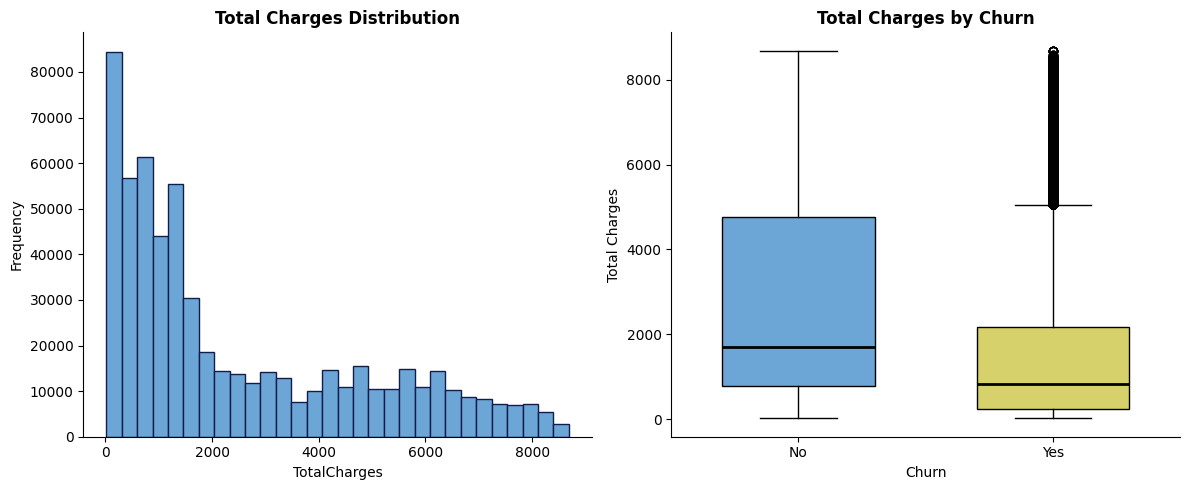

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# PLOT: Histogram
axes[0].hist(
    train["TotalCharges"],
    bins=30,
    color="#6BA6D6",
    edgecolor="#141C4C"
)

axes[0].set_title("Total Charges Distribution", fontweight="bold")
axes[0].set_xlabel("TotalCharges")
axes[0].set_ylabel("Frequency")

axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

# PLOT: Boxplot
data_churn_totalcharges = [
    train[train["Churn"] == "No"]["TotalCharges"],
    train[train["Churn"] == "Yes"]["TotalCharges"]
]

bplot = axes[1].boxplot(
    data_churn_totalcharges,
    patch_artist=True,
    tick_labels=["No", "Yes"],
    widths=0.6,
    medianprops=dict(color="black", linewidth=2)
)

for patch, color in zip(bplot["boxes"], colors):
    patch.set_facecolor(color)

axes[1].set_title("Total Charges by Churn", fontweight="bold")
axes[1].set_xlabel("Churn")
axes[1].set_ylabel("Total Charges")

axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## **B. Multivariate Feature Analysis** <a class="anchor"  id="mfa"></a>

### **📏 Numerical features** <a class="anchor"  id="numerical"></a>

* *Total Charges* is strongly correlated with *tenure* and moderately correlated with *Monthly Charges*.
* *Tenure* and *Monthly Charges* are largely independent.

In [47]:
# Numerical features
num_cols = train[["tenure", "MonthlyCharges", "TotalCharges"]]

In [48]:
# Correlations
corr_matrix = num_cols.corr()

corr_matrix

,tenure,MonthlyCharges,TotalCharges
tenure,1.000000,0.124043,0.769703
MonthlyCharges,0.124043,1.000000,0.634237
TotalCharges,0.769703,0.634237,1.000000


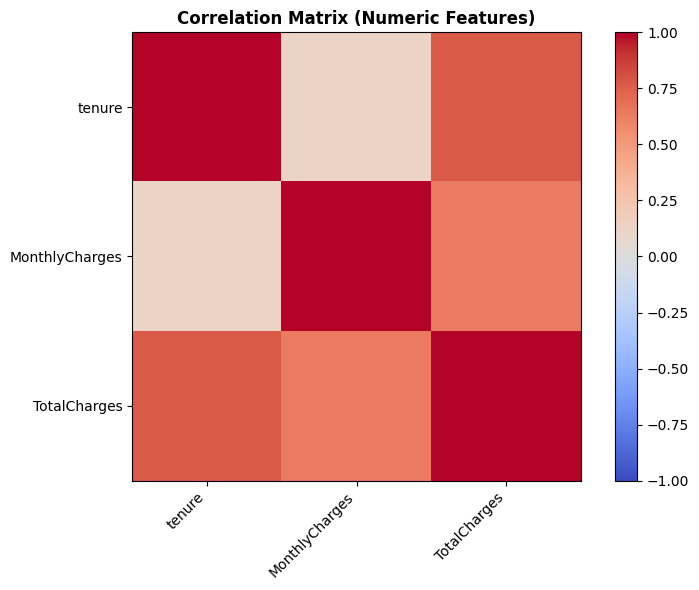

In [49]:
fig, ax = plt.subplots(figsize=(8,6))

cax = ax.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)

# Labels
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha="right")
ax.set_yticklabels(corr_matrix.columns)

# Colorbar
fig.colorbar(cax)

ax.set_title("Correlation Matrix (Numeric Features)", fontweight="bold")

plt.tight_layout()
plt.show()

### **🏷️ Categorical Features** <a class="anchor"  id="categorical"></a>

In [50]:
# Categorical features
cat_cols = train[["gender", "SeniorCitizen", "Partner", 
                  "Dependents", "PhoneService", "MultipleLines", 
                  "InternetService", "OnlineSecurity", "OnlineBackup", 
                  "DeviceProtection", "TechSupport", "StreamingTV",
                  "StreamingMovies", "Contract", "PaperlessBilling", 
                  "PaymentMethod"  
                 ]]

In [51]:
# Significative associations

significant_pairs = []

for col1, col2 in itertools.combinations(cat_cols, 2):
    table = pd.crosstab(train[col1], train[col2])
    chi2, p, _, _ = chi2_contingency(table)
    
    if p < 0.05:
        significant_pairs.append((col1, col2))

print("Significant pairs: ", len(significant_pairs))

Significant pairs:  118


In [52]:
#Cramer's V
def cramers_v(x, y):
    table = pd.crosstab(x, y)
    chi2 = chi2_contingency(table)[0]
    n = table.sum().sum()
    r, k = table.shape
    return np.sqrt(chi2 / (n * (min(r-1, k-1))))

results = []

for col1, col2 in significant_pairs:
    v = cramers_v(train[col1], train[col2])
    results.append((col1, col2, v))

assoc_df = pd.DataFrame(results, columns=["Feature 1", "Feature 2", "Cramers_V"])
assoc_df = assoc_df.sort_values("Cramers_V", ascending=False)

print("Top strongest associations:\n")
print(assoc_df.head(10))

Top strongest associations:

            Feature 1         Feature 2  Cramers_V
52       PhoneService     MultipleLines   1.000000
108       StreamingTV   StreamingMovies   0.811298
84     OnlineSecurity       TechSupport   0.754061
99   DeviceProtection   StreamingMovies   0.748691
98   DeviceProtection       StreamingTV   0.748677
73    InternetService    OnlineSecurity   0.746850
76    InternetService       TechSupport   0.740447
97   DeviceProtection       TechSupport   0.740427
91       OnlineBackup       TechSupport   0.734258
90       OnlineBackup  DeviceProtection   0.732050


# **🔧 3. Feature Engineering (FE)** <a class="anchor"  id="fe"></a>

In [53]:
train_clean = train.copy()

In [54]:
# Categorical to string
for col in cat_cols:
    train_clean[col] = train_clean[col].astype(str).str.strip()

In [55]:
# Target numeric
train_clean["Churn"] = train_clean["Churn"].map({"No": 0, "Yes": 1})

In [56]:
train_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 594194 entries, 0 to 594193
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   gender            594194 non-null  object 
 1   SeniorCitizen     594194 non-null  object 
 2   Partner           594194 non-null  object 
 3   Dependents        594194 non-null  object 
 4   tenure            594194 non-null  int64  
 5   PhoneService      594194 non-null  object 
 6   MultipleLines     594194 non-null  object 
 7   InternetService   594194 non-null  object 
 8   OnlineSecurity    594194 non-null  object 
 9   OnlineBackup      594194 non-null  object 
 10  DeviceProtection  594194 non-null  object 
 11  TechSupport       594194 non-null  object 
 12  StreamingTV       594194 non-null  object 
 13  StreamingMovies   594194 non-null  object 
 14  Contract          594194 non-null  object 
 15  PaperlessBilling  594194 non-null  object 
 16  PaymentMethod     594194 

# **✂️ 4. Data preparation** <a class="anchor"  id="dp"></a>

In [57]:
# Split target and features
X = train_clean.drop(columns=["Churn"])
y = train_clean["Churn"]

In [58]:
# Split train into train and validation
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# **🧠 5. CatBoost** <a class="anchor"  id="cb"></a>

In [59]:
cat_features = [
    "gender", "SeniorCitizen", "Partner", 
    "Dependents", "PhoneService", "MultipleLines", 
    "InternetService", "OnlineSecurity", "OnlineBackup", 
    "DeviceProtection", "TechSupport", "StreamingTV",
    "StreamingMovies", "Contract", "PaperlessBilling", 
    "PaymentMethod"
]

## **A. Training** <a class="anchor"  id="train"></a>

In [60]:
# Model configuration
model = CatBoostClassifier(
    iterations=3000,
    learning_rate=0.03,
    depth=6,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=200,
    early_stopping_rounds=200
)

In [61]:
# Train
model.fit(
    X_train,
    y_train,
    eval_set=(X_val, y_val),
    cat_features=cat_features,
    use_best_model=True
)

0:	test: 0.8749937	best: 0.8749937 (0)	total: 1.07s	remaining: 53m 45s
200:	test: 0.9132821	best: 0.9132821 (200)	total: 1m 45s	remaining: 24m 27s
400:	test: 0.9143842	best: 0.9143842 (400)	total: 3m 22s	remaining: 21m 53s
600:	test: 0.9152463	best: 0.9152463 (600)	total: 5m 10s	remaining: 20m 38s
800:	test: 0.9157297	best: 0.9157297 (800)	total: 7m	remaining: 19m 15s
1000:	test: 0.9160735	best: 0.9160735 (1000)	total: 8m 49s	remaining: 17m 36s
1200:	test: 0.9163028	best: 0.9163028 (1200)	total: 10m 37s	remaining: 15m 54s
1400:	test: 0.9164644	best: 0.9164644 (1400)	total: 12m 25s	remaining: 14m 10s
1600:	test: 0.9165681	best: 0.9165681 (1600)	total: 14m 13s	remaining: 12m 26s
1800:	test: 0.9166647	best: 0.9166648 (1798)	total: 16m 3s	remaining: 10m 41s
2000:	test: 0.9167269	best: 0.9167269 (2000)	total: 17m 54s	remaining: 8m 56s
2200:	test: 0.9167743	best: 0.9167743 (2200)	total: 19m 43s	remaining: 7m 9s
2400:	test: 0.9168261	best: 0.9168269 (2395)	total: 21m 32s	remaining: 5m 22s
260

## **B. Evaluation** <a class="anchor"  id="eval"></a>

In [62]:
# Evaluation
val_preds = model.predict_proba(X_val)[:, 1]

auc = roc_auc_score(y_val, val_preds)
print("Validation AUC:", auc)

Validation AUC: 0.9168822611942015


## **C. Predictions** <a class="anchor"  id="pred"></a>

In [64]:
test_preds = model.predict_proba(test)[:, 1]

# **🚀 6. Submission** <a class="anchor"  id="sub"></a>

In [66]:
submission = pd.DataFrame({
    "id": test.index,
    "Churn": test_preds
})

In [67]:
submission.to_csv("submission.csv", index=False)

In [68]:
submission.head()
submission.shape

(254655, 2)